<a href="https://colab.research.google.com/github/RickV777/ENGAGEMENT_YT/blob/main/YouTube_TFT_Objetivo4_RegresionMultiple.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Notebook 4 — Regresión Lineal Múltiple
### Tesis: Análisis de los Factores Determinantes del Engagement en YouTube
**Objetivo 4:** Construir un modelo de regresión lineal múltiple que explique el engagement en función de las variables identificadas, reportando coeficientes, valores p e intervalos de confianza al 95%.

---
**Flujo del notebook:**
1. Instalación de librerías
2. Carga del dataset procesado
3. Preparación de variables predictoras (numéricas + dummies)
4. Análisis de correlación y multicolinealidad (VIF)
5. Modelo completo — OLS con `statsmodels`
6. Diagnóstico de supuestos (normalidad, homocedasticidad, independencia)
7. Modelo reducido (variables significativas)
8. Visualizaciones de resultados
9. Tabla resumen para la tesis
10. Exportación

## Sección 1 — Instalación de librerías

In [1]:
!pip install statsmodels pingouin -q
print("✅ Listo")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.0/204.0 kB 4.9 MB/s eta 0:00:00
✅ Listo


## Sección 2 — Carga del dataset procesado

In [4]:
import warnings, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan, linear_reset
from statsmodels.stats.stattools import durbin_watson
from scipy import stats
import pingouin as pg

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style('whitegrid')
sns.set_palette('Set2')

# ─── OPCIÓN A: CSV en /content/ ───
#CSV_PATH = '/content/youtube_dataset_procesado.csv'

# ─── OPCIÓN B: desde Google Drive ───
from google.colab import drive
drive.mount('/content/drive')
CSV_PATH = '/content/drive/MyDrive/youtube_dataset_procesado.csv'

df = pd.read_csv(CSV_PATH, low_memory=False)
print(f" Dataset cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"Columnas: {list(df.columns)}")

Mounted at /content/drive
 Dataset cargado: 528,663 filas × 26 columnas
Columnas: ['video_id', 'country', 'publishedAt', 'trending_date', 'publish_hour', 'publish_dayofweek', 'publish_dayname', 'publish_month', 'publish_year', 'franja_horaria', 'dias_hasta_trending', 'category_name', 'title_length', 'num_tags', 'rango_tags', 'rango_titulo', 'comments_disabled', 'ratings_disabled', 'view_count', 'likes', 'comment_count', 'log_views', 'log_likes', 'log_comments', 'engagement_rate', 'log_engagement']


## Sección 3 — Preparación de variables

### Variable dependiente
`engagement_rate` = (likes + comment_count) / view_count

### Variables independientes
| Variable | Tipo | Descripción |
|---|---|---|
| `log_views` | Continua | Log de vistas |
| `log_likes` | Continua | Log de likes |
| `log_comments` | Continua | Log de comentarios |
| `tags_count` | Continua | Número de etiquetas |
| `title_length` | Continua | Longitud del título (caracteres) |
| `days_to_trend` | Continua | Días entre publicación y trending |
| `hour_published` | Continua | Hora de publicación (0–23) |
| `day_of_week` | Continua | Día de la semana (0=Lun) |
| `pais` | Dummy | US (referencia) vs MX |
| `category_name` | Dummy | Categoría del video |

In [6]:
# ─── Calcular variables que puedan faltar ───

df['publishedAt']   = pd.to_datetime(df['publishedAt'],   errors='coerce', utc=True)
df['trending_date'] = pd.to_datetime(df['trending_date'], errors='coerce', utc=True)

if 'days_to_trend' not in df.columns:
    df['days_to_trend'] = (df['trending_date'] - df['publishedAt']).dt.days.clip(lower=0)

if 'tags_count' not in df.columns:
    # Modified to use 'num_tags' as 'tags' column is missing
    if 'num_tags' in df.columns:
        df['tags_count'] = df['num_tags']
    else:
        # Fallback if 'num_tags' is also missing, though unlikely in this context
        df['tags_count'] = 0

if 'title_length' not in df.columns:
    df['title_length'] = df['title'].fillna('').apply(len)

if 'hour_published' not in df.columns:
    df['hour_published'] = df['publishedAt'].dt.hour

if 'day_of_week' not in df.columns:
    df['day_of_week'] = df['publishedAt'].dt.dayofweek

# Transformaciones logarítmicas
for col in ['view_count', 'likes', 'comment_count', 'dislikes']:
    if col in df.columns:
        df[f'log_{col}'] = np.log1p(df[col])

# Winsorización al 99%
cont_vars = ['log_view_count','log_likes','log_comment_count',
             'tags_count','title_length','days_to_trend',
             'hour_published','day_of_week','engagement_rate']
for col in cont_vars:
    if col in df.columns:
        lo, hi = df[col].quantile([0.005, 0.995])
        df[col] = df[col].clip(lo, hi)

# Columna de país homogénea
if 'pais' not in df.columns and 'country' in df.columns:
    df['pais'] = df['country']

# Categoría: quedar con las top 10 para no inflar dummies
if 'category_name' in df.columns:
    top_cats = df['category_name'].value_counts().head(10).index
    df['category_clean'] = df['category_name'].where(df['category_name'].isin(top_cats), 'Otras')
else:
    df['category_clean'] = 'Sin_categoria'

print("✅ Variables preparadas")
print(df[cont_vars].describe().round(3))

✅ Variables preparadas
       log_view_count   log_likes  log_comment_count  tags_count  \
count     528663.0000 528663.0000        528663.0000 528663.0000   
mean          13.7990     10.5900             7.6810     16.2980   
std            1.2010      1.6450             1.7170     12.4560   
min           11.1170      0.0000             0.0000      1.0000   
25%           12.9560      9.7160             6.8390      5.0000   
50%           13.6850     10.6070             7.7070     15.0000   
75%           14.5350     11.5580             8.6380     25.0000   
max           17.6740     14.7970            12.1790     56.0000   

       title_length  days_to_trend  hour_published  day_of_week  \
count   528663.0000    528663.0000     528663.0000  528663.0000   
mean        53.1920         3.9460         13.6150       2.9610   
std         20.9380         2.9540          7.4770       1.9550   
min         10.0000         0.0000          0.0000       0.0000   
25%         38.0000         2

In [7]:
# ─── Crear dataframe de modelado ───
PREDICTORAS = [
    'log_view_count', 'log_likes', 'log_comment_count',
    'tags_count', 'title_length', 'days_to_trend',
    'hour_published', 'day_of_week'
]
PREDICTORAS = [p for p in PREDICTORAS if p in df.columns]

TARGET = 'engagement_rate'

df_model = df[PREDICTORAS + [TARGET, 'pais', 'category_clean']].dropna().copy()

# Dummies: país (referencia = US) y categoría (referencia = más frecuente)
df_model = pd.get_dummies(df_model, columns=['pais', 'category_clean'],
                           drop_first=True, dtype=float)

# Identificar columnas dummy generadas
dummy_cols = [c for c in df_model.columns if c.startswith('pais_') or c.startswith('category_clean_')]

ALL_VARS = PREDICTORAS + dummy_cols

print(f"Registros en modelo: {len(df_model):,}")
print(f"Predictoras totales: {len(ALL_VARS)}")
print(f"  Continuas : {len(PREDICTORAS)}")
print(f"  Dummies   : {len(dummy_cols)}")
print(f"\nDummies generadas: {dummy_cols}")

Registros en modelo: 528,663
Predictoras totales: 19
  Continuas : 8
  Dummies   : 11

Dummies generadas: ['pais_US', 'category_clean_Entertainment', 'category_clean_Film & Animation', 'category_clean_Gaming', 'category_clean_Howto & Style', 'category_clean_Music', 'category_clean_News & Politics', 'category_clean_Otras', 'category_clean_People & Blogs', 'category_clean_Science & Technology', 'category_clean_Sports']


## Sección 4 — Correlación y Multicolinealidad (VIF)

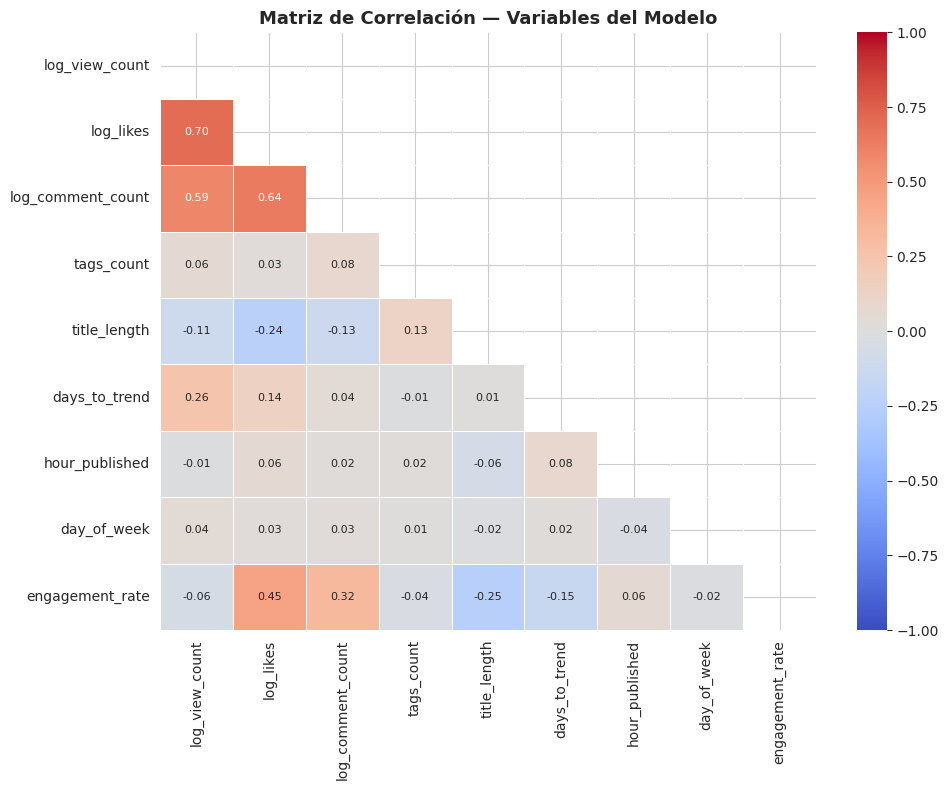

In [8]:
# ─── Matriz de correlación (variables continuas) ───
corr_vars = PREDICTORAS + [TARGET]
corr_matrix = df_model[corr_vars].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, vmin=-1, vmax=1,
            linewidths=0.5, ax=ax, annot_kws={'size': 8})
ax.set_title('Matriz de Correlación — Variables del Modelo', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/nb4_fig1_correlacion.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# ─── VIF — Factor de Inflación de Varianza ───
X_vif = sm.add_constant(df_model[ALL_VARS])

vif_data = pd.DataFrame({
    'Variable': ALL_VARS,
    'VIF': [variance_inflation_factor(X_vif.values, i + 1)
            for i in range(len(ALL_VARS))]
}).sort_values('VIF', ascending=False)

print("FACTOR DE INFLACIÓN DE VARIANZA (VIF)")
print("VIF < 5 → No hay multicolinealidad problemática")
print("VIF > 10 → Multicolinealidad severa (eliminar variable)")
print("=" * 45)
for _, row in vif_data.iterrows():
    flag = " ⚠️  ALTO" if row['VIF'] > 10 else (" ⚡ Moderado" if row['VIF'] > 5 else " ✅")
    print(f"  {row['Variable']:<35}: {row['VIF']:7.2f}{flag}")

# Variables con VIF > 10 (candidatas a eliminar)
vars_high_vif = vif_data[vif_data['VIF'] > 10]['Variable'].tolist()
if vars_high_vif:
    print(f"\n⚠️  Variables con VIF > 10: {vars_high_vif}")
    print("→ Considera eliminarlas del modelo o combinarlas.")
else:
    print("\n✅ Ninguna variable con VIF > 10")

FACTOR DE INFLACIÓN DE VARIANZA (VIF)
VIF < 5 → No hay multicolinealidad problemática
VIF > 10 → Multicolinealidad severa (eliminar variable)
  category_clean_Entertainment       :    4.86 ✅
  category_clean_Music               :    4.62 ✅
  category_clean_Gaming              :    4.28 ✅
  category_clean_Sports              :    3.46 ✅
  category_clean_People & Blogs      :    3.15 ✅
  log_likes                          :    2.79 ✅
  log_view_count                     :    2.45 ✅
  category_clean_News & Politics     :    1.96 ✅
  log_comment_count                  :    1.90 ✅
  category_clean_Otras               :    1.88 ✅
  category_clean_Film & Animation    :    1.74 ✅
  category_clean_Howto & Style       :    1.57 ✅
  category_clean_Science & Technology:    1.44 ✅
  days_to_trend                      :    1.22 ✅
  title_length                       :    1.21 ✅
  pais_US                            :    1.19 ✅
  hour_published                     :    1.08 ✅
  tags_count             

## Sección 5 — Modelo OLS Completo

Estimamos el modelo completo con **Mínimos Cuadrados Ordinarios (OLS)** usando `statsmodels`, que reporta automáticamente coeficientes, valores p e intervalos de confianza al 95%.

In [10]:
# Excluir variables con VIF muy alto si existen
vars_modelo_final = [v for v in ALL_VARS if v not in vars_high_vif]

X = sm.add_constant(df_model[vars_modelo_final])
y = df_model[TARGET]

# ─── Ajustar modelo OLS ───
modelo_completo = sm.OLS(y, X).fit()

print(modelo_completo.summary())

                            OLS Regression Results                            
Dep. Variable:        engagement_rate   R-squared:                       0.563
Model:                            OLS   Adj. R-squared:                  0.563
Method:                 Least Squares   F-statistic:                 3.591e+04
Date:                Mon, 25 May 2026   Prob (F-statistic):               0.00
Time:                        19:33:13   Log-Likelihood:             1.1213e+06
No. Observations:              528663   AIC:                        -2.243e+06
Df Residuals:                  528643   BIC:                        -2.242e+06
Df Model:                          19                                         
Covariance Type:            nonrobust                                         
                                          coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
co

In [11]:
# ─── Resumen ejecutivo del modelo completo ───
r2     = modelo_completo.rsquared
r2_adj = modelo_completo.rsquared_adj
f_stat = modelo_completo.fvalue
f_pval = modelo_completo.f_pvalue
n_obs  = int(modelo_completo.nobs)

print("=" * 55)
print("RESUMEN EJECUTIVO — MODELO COMPLETO")
print("=" * 55)
print(f"  N observaciones : {n_obs:,}")
print(f"  R²              : {r2:.4f}  ({r2*100:.2f}%)")
print(f"  R² ajustado     : {r2_adj:.4f}  ({r2_adj*100:.2f}%)")
print(f"  F-estadístico   : {f_stat:.2f}  (p = {f_pval:.2e})")
sig = "El modelo es estadísticamente significativo (p < 0.05)" if f_pval < 0.05 else "El modelo NO es significativo"
print(f"  → {sig}")

# Variables significativas
params = modelo_completo.params
pvals  = modelo_completo.pvalues
conf   = modelo_completo.conf_int()

sig_vars = pvals[pvals < 0.05].index.tolist()
sig_vars = [v for v in sig_vars if v != 'const']
print(f"\n  Variables significativas (p < 0.05): {len(sig_vars)}")
for v in sig_vars:
    print(f"    → {v}: β = {params[v]:.6f}, p = {pvals[v]:.4f}")

RESUMEN EJECUTIVO — MODELO COMPLETO
  N observaciones : 528,663
  R²              : 0.5634  (56.34%)
  R² ajustado     : 0.5634  (56.34%)
  F-estadístico   : 35910.01  (p = 0.00e+00)
  → El modelo es estadísticamente significativo (p < 0.05)

  Variables significativas (p < 0.05): 19
    → log_view_count: β = -0.025536, p = 0.0000
    → log_likes: β = 0.019087, p = 0.0000
    → log_comment_count: β = 0.006724, p = 0.0000
    → tags_count: β = -0.000077, p = 0.0000
    → title_length: β = -0.000200, p = 0.0000
    → days_to_trend: β = -0.001927, p = 0.0000
    → hour_published: β = 0.000141, p = 0.0000
    → day_of_week: β = -0.000139, p = 0.0000
    → pais_US: β = -0.012628, p = 0.0000
    → category_clean_Entertainment: β = -0.008718, p = 0.0000
    → category_clean_Film & Animation: β = -0.006669, p = 0.0000
    → category_clean_Gaming: β = -0.010596, p = 0.0000
    → category_clean_Howto & Style: β = -0.011141, p = 0.0000
    → category_clean_Music: β = -0.001499, p = 0.0000
    → c

## Sección 6 — Diagnóstico de Supuestos

Un modelo de regresión válido debe cumplir 4 supuestos principales:
1. **Linealidad** — relación lineal entre X e Y
2. **Normalidad de residuos** — residuos distribuidos normalmente
3. **Homocedasticidad** — varianza constante de los residuos
4. **Independencia** — no autocorrelación de residuos (Durbin-Watson)

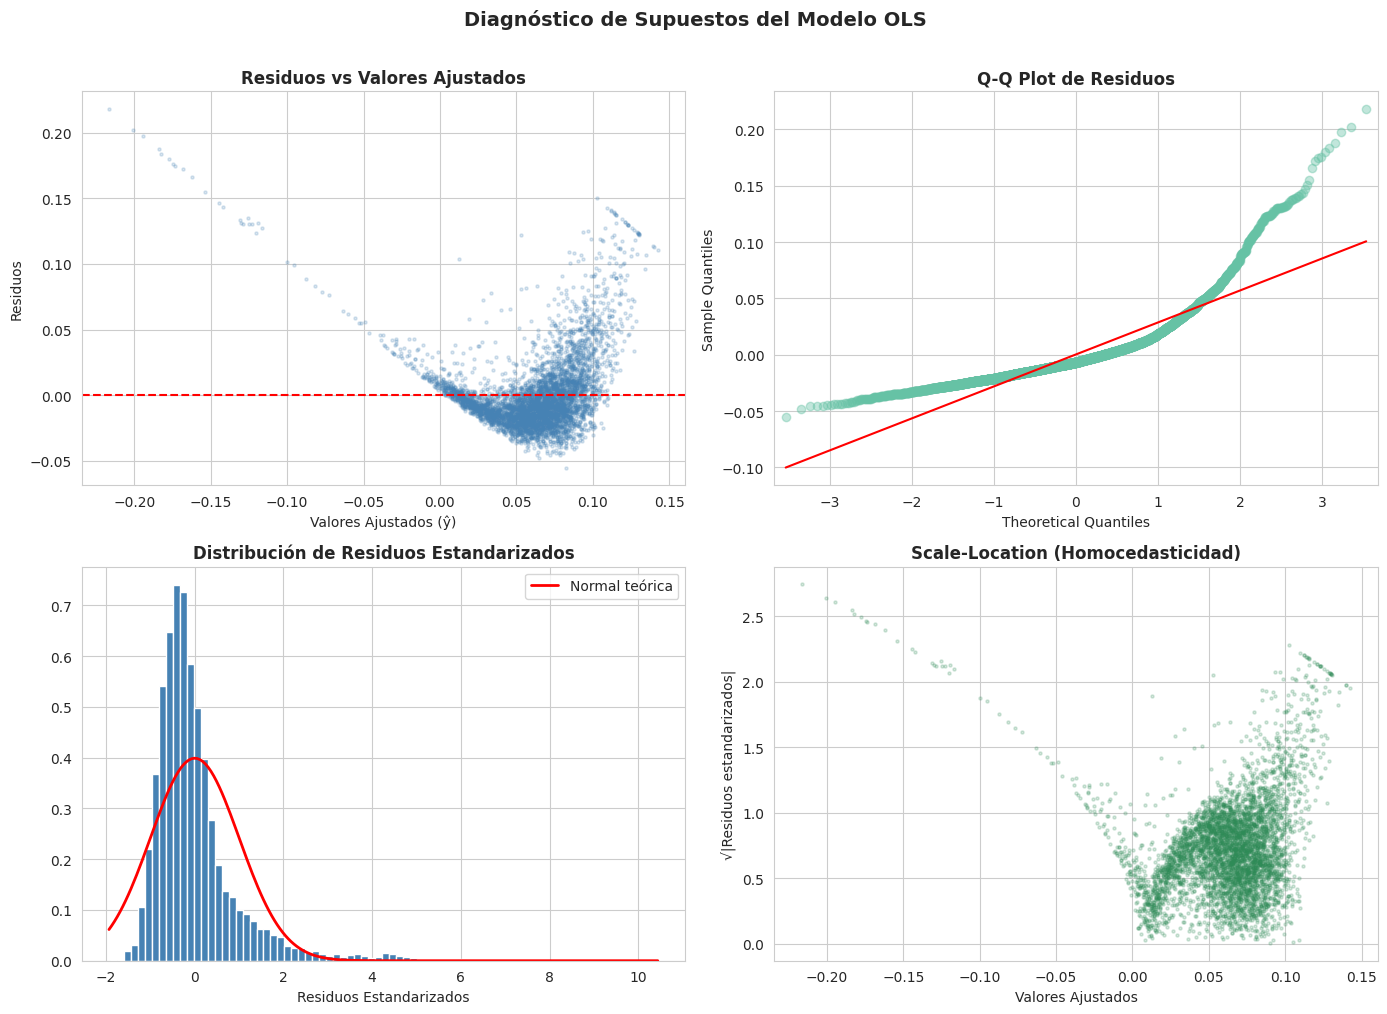

In [12]:
residuos    = modelo_completo.resid
fitted      = modelo_completo.fittedvalues
std_resid   = (residuos - residuos.mean()) / residuos.std()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Residuos vs Fitted
sample_idx = np.random.choice(len(fitted), min(5000, len(fitted)), replace=False)
axes[0,0].scatter(fitted.iloc[sample_idx], residuos.iloc[sample_idx],
                  alpha=0.2, s=5, color='steelblue')
axes[0,0].axhline(0, color='red', lw=1.5, ls='--')
axes[0,0].set_title('Residuos vs Valores Ajustados', fontweight='bold')
axes[0,0].set_xlabel('Valores Ajustados (ŷ)')
axes[0,0].set_ylabel('Residuos')

# 2. Q-Q Plot
sm.qqplot(residuos.iloc[sample_idx], line='s', ax=axes[0,1], alpha=0.4)
axes[0,1].set_title('Q-Q Plot de Residuos', fontweight='bold')

# 3. Histograma de residuos
axes[1,0].hist(std_resid.iloc[sample_idx], bins=60,
               color='steelblue', edgecolor='white', density=True)
xr = np.linspace(std_resid.min(), std_resid.max(), 200)
axes[1,0].plot(xr, stats.norm.pdf(xr), 'r-', lw=2, label='Normal teórica')
axes[1,0].set_title('Distribución de Residuos Estandarizados', fontweight='bold')
axes[1,0].set_xlabel('Residuos Estandarizados')
axes[1,0].legend()

# 4. Scale-Location
axes[1,1].scatter(fitted.iloc[sample_idx], np.sqrt(np.abs(std_resid.iloc[sample_idx])),
                  alpha=0.2, s=5, color='seagreen')
axes[1,1].set_title('Scale-Location (Homocedasticidad)', fontweight='bold')
axes[1,1].set_xlabel('Valores Ajustados')
axes[1,1].set_ylabel('√|Residuos estandarizados|')

plt.suptitle('Diagnóstico de Supuestos del Modelo OLS', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/content/nb4_fig2_diagnostico_supuestos.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
# ─── Pruebas formales de supuestos ───

# Normalidad (muestra por limitación de Shapiro)
muestra_resid = residuos.sample(min(5000, len(residuos)), random_state=42)
_, p_sw = stats.shapiro(muestra_resid)

# Homocedasticidad — Breusch-Pagan
bp_lm, bp_p, bp_f, bp_fp = het_breuschpagan(residuos, X)

# Independencia — Durbin-Watson
dw = durbin_watson(residuos)

print("PRUEBAS FORMALES DE SUPUESTOS")
print("=" * 55)
print(f"\n1. Normalidad (Shapiro-Wilk, n={len(muestra_resid):,}):")
print(f"   p = {p_sw:.4f}  {'✅ Normal' if p_sw >= 0.05 else '⚠️  No normal (frecuente con n grande)'}")
print(f"   → Con n={len(y):,}, es normal que p<0.05 por el teorema del límite central.")
print(f"     Verificar visualmente el Q-Q Plot.")

print(f"\n2. Homocedasticidad (Breusch-Pagan):")
print(f"   LM = {bp_lm:.4f},  p = {bp_p:.4f}")
print(f"   {'✅ Homocedasticidad' if bp_p >= 0.05 else '⚠️  Heterocedasticidad detectada → usar errores robustos (HC3)'}")

print(f"\n3. Independencia (Durbin-Watson):")
print(f"   DW = {dw:.4f}")
if 1.5 <= dw <= 2.5:
    dw_interp = "✅ Sin autocorrelación relevante"
elif dw < 1.5:
    dw_interp = "⚠️  Posible autocorrelación positiva"
else:
    dw_interp = "⚠️  Posible autocorrelación negativa"
print(f"   {dw_interp}  (valor ideal ≈ 2.0)")

PRUEBAS FORMALES DE SUPUESTOS

1. Normalidad (Shapiro-Wilk, n=5,000):
   p = 0.0000  ⚠️  No normal (frecuente con n grande)
   → Con n=528,663, es normal que p<0.05 por el teorema del límite central.
     Verificar visualmente el Q-Q Plot.

2. Homocedasticidad (Breusch-Pagan):
   LM = 112733.4389,  p = 0.0000
   ⚠️  Heterocedasticidad detectada → usar errores robustos (HC3)

3. Independencia (Durbin-Watson):
   DW = 1.8659
   ✅ Sin autocorrelación relevante  (valor ideal ≈ 2.0)


In [14]:
# ─── Modelo robusto (HC3) si hay heterocedasticidad ───
modelo_robusto = modelo_completo.get_robustcov_results(cov_type='HC3')

print("MODELO CON ERRORES ROBUSTOS HC3")
print("(Recomendado cuando hay heterocedasticidad)")
print("=" * 55)
print(modelo_robusto.summary())

MODELO CON ERRORES ROBUSTOS HC3
(Recomendado cuando hay heterocedasticidad)
                            OLS Regression Results                            
Dep. Variable:        engagement_rate   R-squared:                       0.563
Model:                            OLS   Adj. R-squared:                  0.563
Method:                 Least Squares   F-statistic:                 1.864e+04
Date:                Mon, 25 May 2026   Prob (F-statistic):               0.00
Time:                        19:33:54   Log-Likelihood:             1.1213e+06
No. Observations:              528663   AIC:                        -2.243e+06
Df Residuals:                  528643   BIC:                        -2.242e+06
Df Model:                          19                                         
Covariance Type:                  HC3                                         
                                          coef    std err          t      P>|t|      [0.025      0.975]
------------------------------

## Sección 7 — Modelo Reducido (variables significativas)

Reestimamos el modelo conservando solo las variables con p < 0.05 para mayor parsimonia e interpretabilidad.

In [17]:
# Variables significativas del modelo robusto
# Usar model.exog_names para el índice para asegurar compatibilidad
pvals_rob_series = pd.Series(modelo_robusto.pvalues, index=modelo_robusto.model.exog_names)
sig_vars_rob = pvals_rob_series[(pvals_rob_series < 0.05) & (pvals_rob_series.index != 'const')].index.tolist()

print(f"Variables significativas (p < 0.05): {len(sig_vars_rob)}")
for v in sig_vars_rob:
    print(f"  {v}")

if len(sig_vars_rob) >= 2:
    X_red = sm.add_constant(df_model[sig_vars_rob])
    modelo_reducido = sm.OLS(y, X_red).fit().get_robustcov_results(cov_type='HC3')

    print("\n" + "=" * 55)
    print("MODELO REDUCIDO — RESUMEN")
    print("=" * 55)
    print(modelo_reducido.summary())

    print(f"\nR² completo : {modelo_completo.rsquared:.4f}")
    print(f"R² reducido : {modelo_reducido.rsquared:.4f}")
    print(f"Pérdida R²  : {(modelo_completo.rsquared - modelo_reducido.rsquared)*100:.2f} pp")
else:
    modelo_reducido = modelo_robusto
    print("\n→ Se mantiene el modelo completo como referencia.")

Variables significativas (p < 0.05): 19
  log_view_count
  log_likes
  log_comment_count
  tags_count
  title_length
  days_to_trend
  hour_published
  day_of_week
  pais_US
  category_clean_Entertainment
  category_clean_Film & Animation
  category_clean_Gaming
  category_clean_Howto & Style
  category_clean_Music
  category_clean_News & Politics
  category_clean_Otras
  category_clean_People & Blogs
  category_clean_Science & Technology
  category_clean_Sports

MODELO REDUCIDO — RESUMEN
                            OLS Regression Results                            
Dep. Variable:        engagement_rate   R-squared:                       0.563
Model:                            OLS   Adj. R-squared:                  0.563
Method:                 Least Squares   F-statistic:                 1.864e+04
Date:                Mon, 25 May 2026   Prob (F-statistic):               0.00
Time:                        19:39:01   Log-Likelihood:             1.1213e+06
No. Observations:              5

## Sección 8 — Visualización de Resultados

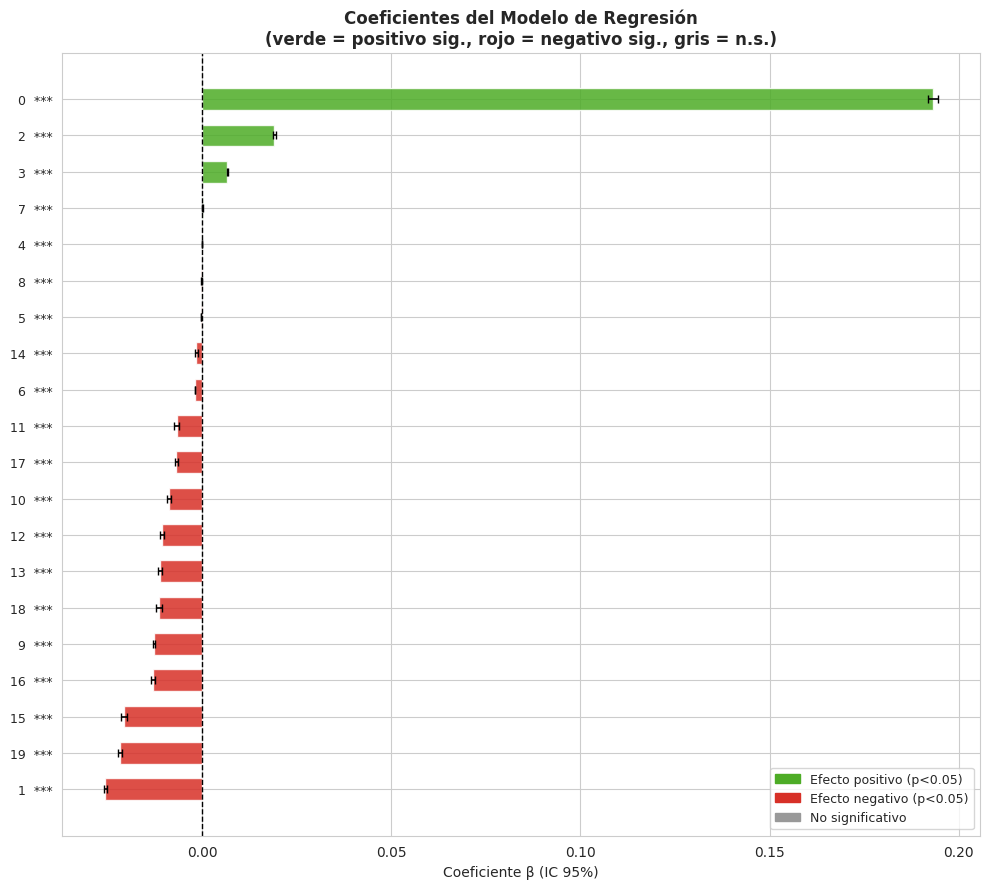

In [22]:
# ─── Coeficientes con IC 95% (modelo reducido o robusto) ───
modelo_viz = modelo_reducido if len(sig_vars_rob) >= 2 else modelo_robusto

# Initialize DataFrame with params to set the index
coef_df = pd.DataFrame({'coef': modelo_viz.params})

# Add other columns, ensuring index alignment
ci_df = modelo_viz.conf_int()
coef_df['ci_low'] = ci_df[:, 0] # Correctly select the first column for lower CI
coef_df['ci_high'] = ci_df[:, 1] # Correctly select the second column for upper CI
coef_df['pval'] = modelo_viz.pvalues

# Now drop 'const'
coef_df = coef_df.drop(index='const', errors='ignore')

coef_df = coef_df.sort_values('coef', ascending=True)
coef_df['sig'] = coef_df['pval'].apply(
    lambda p: '***' if p<0.001 else ('**' if p<0.01 else ('*' if p<0.05 else 'n.s.')))
coef_df['color'] = coef_df.apply(
    lambda r: '#d73027' if r['coef'] < 0 and r['pval'] < 0.05
              else ('#4dac26' if r['coef'] >= 0 and r['pval'] < 0.05 else '#999999'), axis=1)

fig, ax = plt.subplots(figsize=(10, max(6, len(coef_df) * 0.45)))
y_pos = range(len(coef_df))

ax.barh(y_pos, coef_df['coef'], color=coef_df['color'], edgecolor='white', height=0.6, alpha=0.85)
ax.errorbar(coef_df['coef'], y_pos,
            xerr=[coef_df['coef'] - coef_df['ci_low'],
                  coef_df['ci_high'] - coef_df['coef']],
            fmt='none', color='black', capsize=3, lw=1.2)
ax.axvline(0, color='black', lw=1, ls='--')
ax.set_yticks(list(y_pos))
ax.set_yticklabels([f"{v}  {s}" for v, s in zip(coef_df.index, coef_df['sig'])], fontsize=9)
ax.set_xlabel('Coeficiente β (IC 95%)')
ax.set_title('Coeficientes del Modelo de Regresión\n(verde = positivo sig., rojo = negativo sig., gris = n.s.)',
             fontweight='bold', fontsize=12)

patches = [mpatches.Patch(color='#4dac26', label='Efecto positivo (p<0.05)'),
           mpatches.Patch(color='#d73027', label='Efecto negativo (p<0.05)'),
           mpatches.Patch(color='#999999', label='No significativo')]
ax.legend(handles=patches, loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig('/content/nb4_fig3_coeficientes.png', dpi=150, bbox_inches='tight')
plt.show()

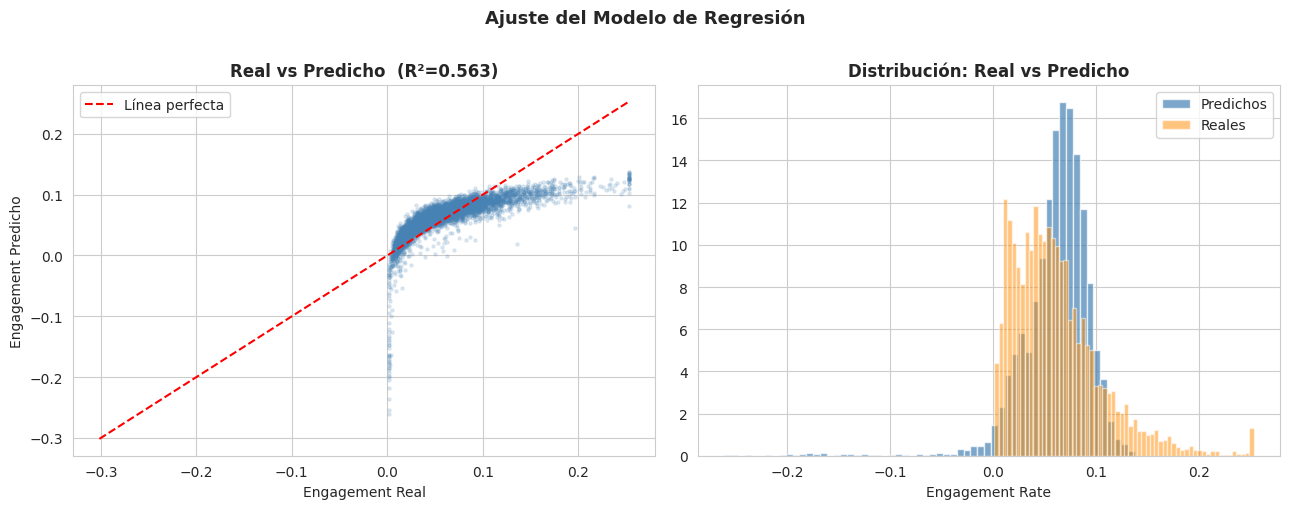

In [24]:
# ─── Valores reales vs predichos ───
y_pred = modelo_viz.fittedvalues
sample_idx = np.random.choice(len(y), min(5000, len(y)), replace=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y.iloc[sample_idx], y_pred[sample_idx],
                alpha=0.15, s=5, color='steelblue')
lims = [min(y.min(), y_pred.min()), max(y.max(), y_pred.max())]
axes[0].plot(lims, lims, 'r--', lw=1.5, label='Línea perfecta')
axes[0].set_xlabel('Engagement Real')
axes[0].set_ylabel('Engagement Predicho')
axes[0].set_title(f'Real vs Predicho  (R²={modelo_viz.rsquared:.3f})', fontweight='bold')
axes[0].legend()

axes[1].hist(y_pred[sample_idx], bins=60, color='steelblue', edgecolor='white',
             density=True, alpha=0.7, label='Predichos')
axes[1].hist(y.iloc[sample_idx], bins=60, color='darkorange', edgecolor='white',
             density=True, alpha=0.5, label='Reales')
axes[1].set_title('Distribución: Real vs Predicho', fontweight='bold')
axes[1].set_xlabel('Engagement Rate')
axes[1].legend()

plt.suptitle('Ajuste del Modelo de Regresión', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/content/nb4_fig4_real_vs_predicho.png', dpi=150, bbox_inches='tight')
plt.show()

## Sección 9 — Tabla Resumen para la Tesis

In [27]:
# ─── Tabla lista para insertar en el Capítulo IV ───
tabla_tesis = pd.DataFrame({
    'Variable':             modelo_viz.model.exog_names,
    'Coeficiente_β':        modelo_viz.params.round(6),
    'Error_Estándar':       modelo_viz.bse.round(6),
    't_estadístico':        modelo_viz.tvalues.round(4),
    'p_valor':              modelo_viz.pvalues.round(4),
    'IC_95%_Inferior':      modelo_viz.conf_int()[:, 0].round(6),
    'IC_95%_Superior':      modelo_viz.conf_int()[:, 1].round(6),
})

def sig_label(p):
    if p < 0.001: return '***'
    elif p < 0.01: return '**'
    elif p < 0.05: return '*'
    else: return 'n.s.'

tabla_tesis['Significancia'] = tabla_tesis['p_valor'].apply(sig_label)

print("TABLA DE COEFICIENTES — MODELO DE REGRESIÓN MÚLTIPLE")
print("Significancia: *** p<0.001 | ** p<0.01 | * p<0.05 | n.s. no significativo")
print("=" * 85)
print(tabla_tesis.to_string(index=False))

print(f"\nR² = {modelo_viz.rsquared:.4f}  |  R² ajustado = {modelo_viz.rsquared_adj:.4f}")
print(f"F({int(modelo_viz.df_model)}, {int(modelo_viz.df_resid)}) = {modelo_viz.fvalue:.2f},  p = {modelo_viz.f_pvalue:.2e}")
print(f"N = {int(modelo_viz.nobs):,}")

TABLA DE COEFICIENTES — MODELO DE REGRESIÓN MÚLTIPLE
Significancia: *** p<0.001 | ** p<0.01 | * p<0.05 | n.s. no significativo
                           Variable  Coeficiente_β  Error_Estándar  t_estadístico  p_valor  IC_95%_Inferior  IC_95%_Superior Significancia
                              const         0.1932          0.0007       266.0314   0.0000           0.1917           0.1946           ***
                     log_view_count        -0.0255          0.0002      -145.7589   0.0000          -0.0259          -0.0252           ***
                          log_likes         0.0191          0.0002       101.6796   0.0000           0.0187           0.0195           ***
                  log_comment_count         0.0067          0.0001        97.6360   0.0000           0.0066           0.0069           ***
                         tags_count        -0.0001          0.0000       -19.5041   0.0000          -0.0001          -0.0001           ***
                       title_length    

## Sección 10 — Exportación de resultados

In [28]:
# ─── Guardar todos los artefactos del NB4 ───

# 1. Tabla de coeficientes
tabla_tesis.to_csv('/content/nb4_tabla_coeficientes.csv', index=False)

# 2. Resumen estadístico del modelo
with open('/content/nb4_resumen_modelo.txt', 'w') as f:
    f.write(str(modelo_viz.summary()))

# 3. VIF
vif_data.to_csv('/content/nb4_vif.csv', index=False)

# 4. Tabla diagnóstico de supuestos
diagnostico = pd.DataFrame({
    'Supuesto':     ['Normalidad residuos (Shapiro-Wilk)',
                     'Homocedasticidad (Breusch-Pagan)',
                     'Independencia (Durbin-Watson)'],
    'Estadístico':  [f'p={p_sw:.4f}', f'LM={bp_lm:.4f}, p={bp_p:.4f}', f'DW={dw:.4f}'],
    'Resultado':    [
        'No normal (esperado con n grande)' if p_sw < 0.05 else 'Normal',
        'Heterocedasticidad → errores HC3' if bp_p < 0.05 else 'Homocedasticidad',
        dw_interp
    ]
})
diagnostico.to_csv('/content/nb4_diagnostico_supuestos.csv', index=False)

print("✅ Archivos exportados:")
for f in sorted(os.listdir('/content/')):
    if f.startswith('nb4_'):
        sz = os.path.getsize(f'/content/{f}')
        print(f"  📄 {f} ({sz/1024:.1f} KB)")

✅ Archivos exportados:
  📄 nb4_diagnostico_supuestos.csv (0.3 KB)
  📄 nb4_fig1_correlacion.png (117.1 KB)
  📄 nb4_fig2_diagnostico_supuestos.png (391.2 KB)
  📄 nb4_fig3_coeficientes.png (85.5 KB)
  📄 nb4_fig4_real_vs_predicho.png (111.2 KB)
  📄 nb4_resumen_modelo.txt (3.8 KB)
  📄 nb4_tabla_coeficientes.csv (1.5 KB)
  📄 nb4_vif.csv (0.7 KB)
